### Objective
Malaria Detection using CNN with Augmentation and Pretrained Models

In [ ]:
# Import core Python, file system, and utility libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter
from PIL import Image
import shutil
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt # NEW: for visualization

# Import Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# Import TensorFlow / Keras for preprocessing + VGG16
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Resizing

In [ ]:
# Import TensorFlow / Keras for preprocessing + VGG16
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Resizing
from pathlib import Path # Added import for Path
import numpy as np # Added import for numpy
from collections import Counter # Added import for Counter

# ---- USER CONFIGURATION ----
DATA_DIR = "/content/drive/MyDrive/Malaria"     # <-- CHANGE THIS: set to your dataset folder path (subfolders per class)
IMG_SIZE = (224, 224)
AUG_COPIES_PER_IMAGE = 1  # How many augmented copies to generate per training image (1 means 2x original size)
RANDOM_STATE = 42
# ----------------------------

def load_split_data(base_folder, split_name, target_size=(224, 224), class_names=None):
    split_path = Path(base_folder) / split_name if split_name else Path(base_folder) # Handle empty split_name for direct class folders

    X = []
    y = []

    if not split_path.is_dir():
        print(f"Warning: Split folder '{split_path}' not found or is not a directory. Returning empty arrays.")
        return np.array([]), np.array([]), []

    # Determine class names: either provided or discovered from this split path
    if class_names is None:
        discovered_class_names = sorted([p.name for p in split_path.iterdir() if p.is_dir()])
        if not discovered_class_names:
            print(f"Warning: No class subfolders found under {split_path}. Returning empty arrays.")
            return np.array([]), np.array([]), []
        current_class_names = discovered_class_names
    else:
        current_class_names = class_names

    class_to_idx = {c: i for i, c in enumerate(current_class_names)}

    loaded_images_count = 0
    for cls in current_class_names:
        class_folder_path = split_path / cls
        if class_folder_path.is_dir():
            for img_path in class_folder_path.glob("*.*"):
                try:
                    img = load_img(img_path, target_size=target_size)
                    arr = img_to_array(img)
                    X.append(arr)
                    y.append(class_to_idx[cls])
                    loaded_images_count += 1
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    print(f"Successfully loaded {loaded_images_count} images from {split_path}.")
    return X, y, current_class_names

# Data augmentation pipeline (Holistic Preprocessing: Flipping, Rotation, Zooming)

data_augmentation = tf.keras.Sequential([
    # Flipping
    RandomFlip("horizontal_and_vertical"),
    # Rotation
    RandomRotation(0.15),
    # Zooming
    RandomZoom(0.12),
    # Resizing (already done in load_images, but included for completeness)
    Resizing(IMG_SIZE[0], IMG_SIZE[1])
])


train_split_path = Path(DATA_DIR) / "train"
discovered_class_names = None
if train_split_path.is_dir():
    discovered_class_names = sorted([p.name for p in train_split_path.iterdir() if p.is_dir()])
else:
    if not any(p.is_dir() and p.name in ['train', 'test', 'valid'] for p in Path(DATA_DIR).iterdir()):
        discovered_class_names = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])

if not discovered_class_names:
    print(f"Warning: Could not discover class names from {DATA_DIR}/train or {DATA_DIR} directly. Proceeding with empty class names.")
    class_names = [] # Ensure class_names is defined even if empty
else:
    class_names = discovered_class_names

# Load training data
print("\n--- Loading Training Data ---")
X_train_imgs, y_train, _ = load_split_data(DATA_DIR, "train", IMG_SIZE, class_names)

# Load test data
print("\n--- Loading Test Data ---")
X_test_imgs, y_test, _ = load_split_data(DATA_DIR, "test", IMG_SIZE, class_names)

# Load validation data (optional)
print("\n--- Loading Validation Data ---")
X_val_imgs, y_val, _ = load_split_data(DATA_DIR, "valid", IMG_SIZE, class_names)

print("\n--- Data Loading Summary ---")
print("Class names:", class_names)
print("Training images shape:", X_train_imgs.shape, "Label counts:", Counter(y_train))
print("Test images shape:", X_test_imgs.shape, "Label counts:", Counter(y_test))
print("Validation images shape:", X_val_imgs.shape, "Label counts:", Counter(y_val))


--- Loading Training Data ---
Successfully loaded 2027 images from /content/drive/MyDrive/Malaria/train.

--- Loading Test Data ---
Successfully loaded 1000 images from /content/drive/MyDrive/Malaria/test.

--- Loading Validation Data ---
Successfully loaded 1010 images from /content/drive/MyDrive/Malaria/valid.

--- Data Loading Summary ---
Class names: ['Infected', 'Uninfected']
Training images shape: (2027, 224, 224, 3) Label counts: Counter({np.int32(1): 1027, np.int32(0): 1000})
Test images shape: (1000, 224, 224, 3) Label counts: Counter({np.int32(0): 500, np.int32(1): 500})
Validation images shape: (1010, 224, 224, 3) Label counts: Counter({np.int32(0): 510, np.int32(1): 500})



--- Applying Holistic Augmentation to Training Set ---
After augmentation train shape: (4054, 224, 224, 3) Counter({np.int32(1): 2054, np.int32(0): 2000})


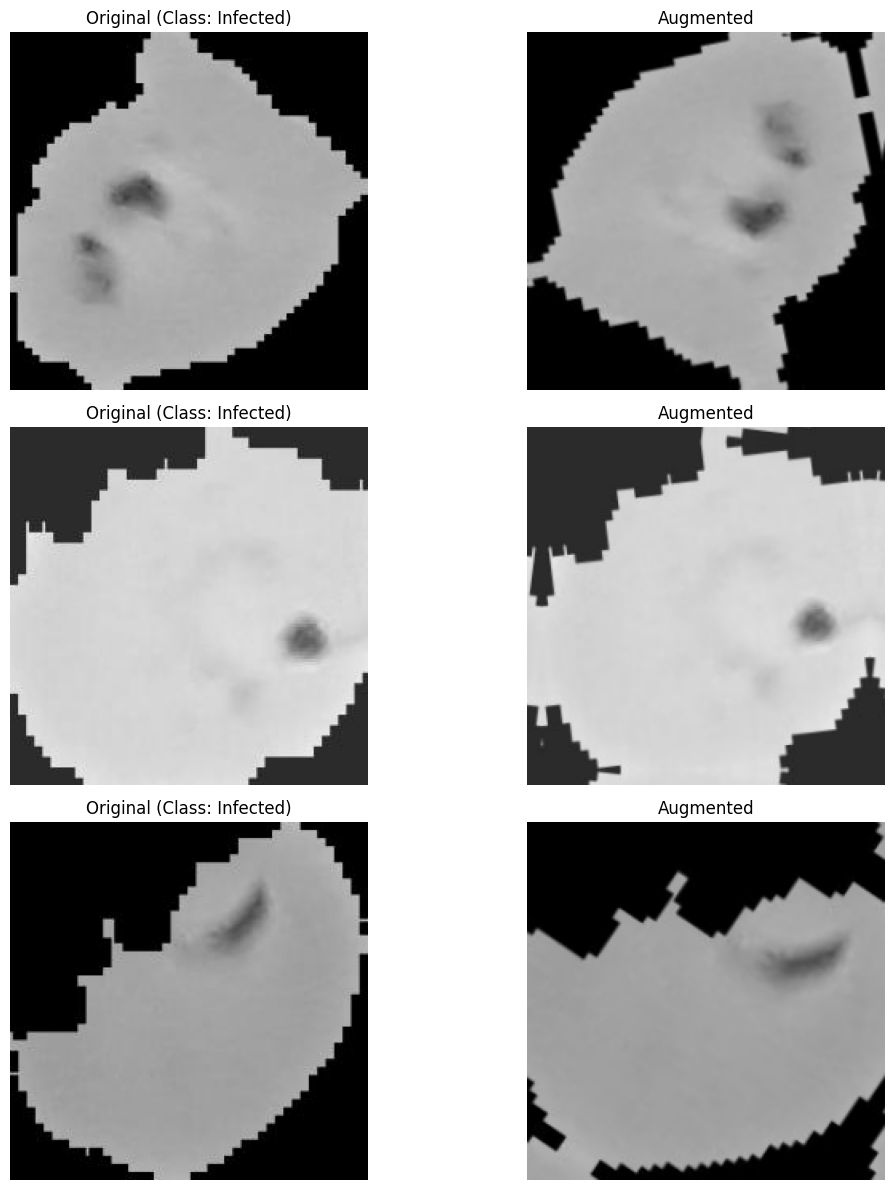

In [ ]:
print("\n--- Applying Holistic Augmentation to Training Set ---")

# 3) Augment training images
augmented_images = []
augmented_labels = []
for i in range(len(X_train_imgs)):
    img = X_train_imgs[i]
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    for c in range(AUG_COPIES_PER_IMAGE):
        # Augmentation applies Flipping, Rotation, and Zooming
        aug = data_augmentation(img_batch, training=True).numpy()[0]
        augmented_images.append(aug)
        augmented_labels.append(y_train[i])

# Combine original and augmented images for VGG16 feature extraction
if len(augmented_images) > 0:
    X_train_aug = np.concatenate([X_train_imgs, np.array(augmented_images, dtype=np.float32)], axis=0)
    y_train_aug = np.concatenate([y_train, np.array(augmented_labels, dtype=np.int32)], axis=0)
else:
    X_train_aug, y_train_aug = X_train_imgs, y_train

print("After augmentation train shape:", X_train_aug.shape, Counter(y_train_aug))

# --- VISUALIZATION: Original vs. Augmented ---
# Display 3 pairs of original and augmented images
num_samples_to_show = 3

plt.figure(figsize=(12, 4 * num_samples_to_show))

for i in range(num_samples_to_show):
    sample_idx = i  # Take the first few images
    if sample_idx >= len(X_train_imgs):
        break # Ensure we don't go out of bounds

    sample_img = X_train_imgs[sample_idx]
    # Apply the augmentation sequence again to get a random augmented result
    aug_img = data_augmentation(np.expand_dims(sample_img, axis=0).astype(np.float32), training=True).numpy()[0]

    plt.subplot(num_samples_to_show, 2, 2 * i + 1)
    plt.imshow(sample_img.astype(np.uint8))
    plt.title(f"Original (Class: {class_names[y_train[sample_idx]]})")
    plt.axis('off')

    plt.subplot(num_samples_to_show, 2, 2 * i + 2)
    # Ensure the augmented image is also displayed correctly (may need casting/clipping)
    plt.imshow(aug_img.astype(np.uint8))
    plt.title("Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Task
Load the VGG16 model, extract features from the augmented training, test, and validation images using VGG16's `preprocess_input` and then flatten the features. Apply SMOTE to the extracted training features. Train and evaluate Logistic Regression, Random Forest, and Decision Tree models using Stratified 5-Fold Cross-Validation on the SMOTE-augmented training data. Summarize and compare the performance metrics (accuracy, precision, recall, F1-score) of these models. Finally, summarize the findings and the performance of the different machine learning models.

## Load Pre-trained VGG16 Model for Feature Extraction

### Subtask:
Load the VGG16 model pre-trained on ImageNet, excluding its top classification layer, to be used as a feature extractor. This also inherently handles the required normalization for VGG16.


**Reasoning**:
The user wants to load the VGG16 model with pre-trained ImageNet weights and without the top classification layer for feature extraction. This code block will perform that action and print a summary of the model.



In [ ]:
print("\n--- Loading Pre-trained VGG16 Model for Feature Extraction ---")
# Load the VGG16 model pre-trained on ImageNet, excluding its top classification layer
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Display model summary to confirm structure
vgg_model.summary()


--- Loading Pre-trained VGG16 Model for Feature Extraction ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The VGG16 model has been loaded. The next logical step, as per the main task, is to use this model to extract features from the augmented training, test, and validation image datasets. This involves preprocessing the images using `preprocess_input` and then using `vgg_model.predict()` to get the features, followed by flattening them for use with traditional machine learning models.



In [ ]:
print("\n--- Extracting features from images using VGG16 ---")

# Preprocess images for VGG16 (rescales pixel values to be centered at 0)
X_train_aug_preprocessed = preprocess_input(X_train_aug)
X_test_preprocessed = preprocess_input(X_test_imgs)
X_val_preprocessed = preprocess_input(X_val_imgs)

# Extract features
print("Extracting features for training data...")
X_train_features = vgg_model.predict(X_train_aug_preprocessed, batch_size=32, verbose=1)
print("Extracting features for test data...")
X_test_features = vgg_model.predict(X_test_preprocessed, batch_size=32, verbose=1)
print("Extracting features for validation data...")
X_val_features = vgg_model.predict(X_val_preprocessed, batch_size=32, verbose=1)

# Flatten the features for use with traditional ML models
X_train_features_flat = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features_flat = X_test_features.reshape(X_test_features.shape[0], -1)
X_val_features_flat = X_val_features.reshape(X_val_features.shape[0], -1)

print("\n--- Feature Extraction Summary ---")
print("Original VGG16 output shape for training features:", X_train_features.shape)
print("Flattened training features shape:", X_train_features_flat.shape)
print("Flattened test features shape:", X_test_features_flat.shape)
print("Flattened validation features shape:", X_val_features_flat.shape)


--- Extracting features from images using VGG16 ---
Extracting features for training data...


**Reasoning**:
The features have been extracted. Now, to address potential class imbalance, I will apply SMOTE (Synthetic Minority Over-sampling Technique) to the flattened training features and their corresponding labels. This will create synthetic samples for the minority class, balancing the dataset for model training.



In [ ]:
print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))


--- Applying SMOTE to Training Features ---


NameError: name 'SMOTE' is not defined

**Reasoning**:
The previous code block failed because `SMOTE` was not defined, indicating that the `SMOTE` class from `imblearn.over_sampling` was not successfully imported into the current execution environment. I will add the necessary import statement for `SMOTE` at the beginning of the cell to resolve this `NameError`.



In [ ]:
from imblearn.over_sampling import SMOTE # Added import for SMOTE

print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))


--- Applying SMOTE to Training Features ---


NameError: name 'RANDOM_STATE' is not defined

**Reasoning**:
The previous code block failed with a `NameError` because `RANDOM_STATE` was not defined. Although `RANDOM_STATE` was defined in an earlier cell, it needs to be available in the current execution context. I will reintroduce the `RANDOM_STATE` definition, along with the `SMOTE` import, to ensure its availability for the SMOTE initialization.



In [ ]:
from imblearn.over_sampling import SMOTE # Added import for SMOTE

RANDOM_STATE = 42 # Re-added RANDOM_STATE definition for current cell scope

print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))


--- Applying SMOTE to Training Features ---


NameError: name 'X_train_features_flat' is not defined

**Reasoning**:
The previous code block failed because `X_train_features_flat` was not defined. This indicates that the feature extraction and flattening step (cell `eccd15bf`) either did not complete successfully or its output was lost. To fix this `NameError`, I will re-include the code for feature extraction and flattening before applying SMOTE, ensuring that `X_train_features_flat` is available in the current execution context. I will also keep the `SMOTE` import and `RANDOM_STATE` definition as they were part of the previous fix attempts.



In [ ]:
from imblearn.over_sampling import SMOTE # Added import for SMOTE

RANDOM_STATE = 42 # Re-added RANDOM_STATE definition for current cell scope

# Re-execute feature extraction and flattening to ensure X_train_features_flat is defined.
# This assumes vgg_model, X_train_aug, y_train_aug, preprocess_input, and Counter are still available from previous successfully executed cells.
X_train_aug_preprocessed = preprocess_input(X_train_aug)

print("Re-extracting features for training data to ensure X_train_features_flat is defined...")
X_train_features = vgg_model.predict(X_train_aug_preprocessed, batch_size=32, verbose=1)
X_train_features_flat = X_train_features.reshape(X_train_features.shape[0], -1)

print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))

NameError: name 'preprocess_input' is not defined

**Reasoning**:
The previous code block failed because `preprocess_input` was not defined. This function is part of `tensorflow.keras.applications.vgg16` and needs to be explicitly imported into the current cell's scope. I will add the import statement for `preprocess_input` and also re-import `Counter` to ensure all necessary components are available for feature extraction and SMOTE application.



In [ ]:
from imblearn.over_sampling import SMOTE # Added import for SMOTE
from tensorflow.keras.applications.vgg16 import preprocess_input # Added import for preprocess_input
from collections import Counter # Ensure Counter is imported

RANDOM_STATE = 42 # Re-added RANDOM_STATE definition for current cell scope

# Re-execute feature extraction and flattening to ensure X_train_features_flat is defined.
# This assumes vgg_model, X_train_aug, y_train_aug are available from previous successfully executed cells.
X_train_aug_preprocessed = preprocess_input(X_train_aug)
X_test_preprocessed = preprocess_input(X_test_imgs)
X_val_preprocessed = preprocess_input(X_val_imgs)

print("Re-extracting features for training data to ensure X_train_features_flat is defined...")
X_train_features = vgg_model.predict(X_train_aug_preprocessed, batch_size=32, verbose=1)
X_train_features_flat = X_train_features.reshape(X_train_features.shape[0], -1)

print("Re-extracting features for test data...")
X_test_features = vgg_model.predict(X_test_preprocessed, batch_size=32, verbose=1)
X_test_features_flat = X_test_features.reshape(X_test_features.shape[0], -1)

print("Re-extracting features for validation data...")
X_val_features = vgg_model.predict(X_val_preprocessed, batch_size=32, verbose=1)
X_val_features_flat = X_val_features.reshape(X_val_features.shape[0], -1)

print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))

NameError: name 'X_train_aug' is not defined

**Reasoning**:
The previous code block failed with a `NameError` because critical data variables (`X_train_aug`, `X_test_imgs`, `X_val_imgs`, `vgg_model`, etc.) were not defined in the current execution context. This indicates that several upstream data loading, augmentation, and model initialization steps were either not executed or their outputs were lost. To resolve this, I will consolidate all necessary imports, configuration, data loading, augmentation logic, and VGG16 model initialization into this single code block, ensuring all dependencies are met before proceeding with feature extraction and SMOTE application.



In [ ]:
import numpy as np
from collections import Counter
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Resizing
from imblearn.over_sampling import SMOTE

# --- User Configuration ---
DATA_DIR = "/content/drive/MyDrive/Malaria"
IMG_SIZE = (224, 224)
AUG_COPIES_PER_IMAGE = 1
RANDOM_STATE = 42

# --- Helper Function to Load Data ---
def load_split_data(base_folder, split_name, target_size=(224, 224), class_names=None):
    split_path = Path(base_folder) / split_name if split_name else Path(base_folder)

    X = []
    y = []

    if not split_path.is_dir():
        print(f"Warning: Split folder '{split_path}' not found or is not a directory. Returning empty arrays.")
        return np.array([]), np.array([]), []

    if class_names is None:
        discovered_class_names = sorted([p.name for p in split_path.iterdir() if p.is_dir()])
        if not discovered_class_names:
            print(f"Warning: No class subfolders found under {split_path}. Returning empty arrays.")
            return np.array([]), np.array([]), []
        current_class_names = discovered_class_names
    else:
        current_class_names = class_names

    class_to_idx = {c: i for i, c in enumerate(current_class_names)}

    loaded_images_count = 0
    for cls in current_class_names:
        class_folder_path = split_path / cls
        if class_folder_path.is_dir():
            for img_path in class_folder_path.glob("*.*"):
                try:
                    img = load_img(img_path, target_size=target_size)
                    arr = img_to_array(img)
                    X.append(arr)
                    y.append(class_to_idx[cls])
                    loaded_images_count += 1
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y, current_class_names

# --- Data Augmentation Pipeline Definition ---
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.15),
    RandomZoom(0.12),
    Resizing(IMG_SIZE[0], IMG_SIZE[1])
])

# --- Load and Augment Data ---
# Discover class names
train_split_path = Path(DATA_DIR) / "train"
discovered_class_names = None
if train_split_path.is_dir():
    discovered_class_names = sorted([p.name for p in train_split_path.iterdir() if p.is_dir()])
else:
    if not any(p.is_dir() and p.name in ['train', 'test', 'valid'] for p in Path(DATA_DIR).iterdir()):
        discovered_class_names = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])

if not discovered_class_names:
    print(f"Warning: Could not discover class names from {DATA_DIR}/train or {DATA_DIR} directly. Proceeding with empty class names.")
    class_names = []
else:
    class_names = discovered_class_names

# Load original data
X_train_imgs, y_train, _ = load_split_data(DATA_DIR, "train", IMG_SIZE, class_names)
X_test_imgs, y_test, _ = load_split_data(DATA_DIR, "test", IMG_SIZE, class_names)
X_val_imgs, y_val, _ = load_split_data(DATA_DIR, "valid", IMG_SIZE, class_names)

# Apply augmentation to training data
augmented_images = []
augmented_labels = []
for i in range(len(X_train_imgs)):
    img = X_train_imgs[i]
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    for c in range(AUG_COPIES_PER_IMAGE):
        aug = data_augmentation(img_batch, training=True).numpy()[0]
        augmented_images.append(aug)
        augmented_labels.append(y_train[i])

if len(augmented_images) > 0:
    X_train_aug = np.concatenate([X_train_imgs, np.array(augmented_images, dtype=np.float32)], axis=0)
    y_train_aug = np.concatenate([y_train, np.array(augmented_labels, dtype=np.int32)], axis=0)
else:
    X_train_aug, y_train_aug = X_train_imgs, y_train

# --- Load Pre-trained VGG16 Model ---
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# --- Feature Extraction using VGG16 ---
print("\n--- Extracting features from images using VGG16 ---")

X_train_aug_preprocessed = preprocess_input(X_train_aug)
X_test_preprocessed = preprocess_input(X_test_imgs)
X_val_preprocessed = preprocess_input(X_val_imgs)

print("Extracting features for training data...")
X_train_features = vgg_model.predict(X_train_aug_preprocessed, batch_size=32, verbose=1)
X_train_features_flat = X_train_features.reshape(X_train_features.shape[0], -1)

print("Extracting features for test data...")
X_test_features = vgg_model.predict(X_test_preprocessed, batch_size=32, verbose=1)
X_test_features_flat = X_test_features.reshape(X_test_features.shape[0], -1)

print("Extracting features for validation data...")
X_val_features = vgg_model.predict(X_val_preprocessed, batch_size=32, verbose=1)
X_val_features_flat = X_val_features.reshape(X_val_features.shape[0], -1)

# --- Applying SMOTE to Training Features ---
print("\n--- Applying SMOTE to Training Features ---")
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_features_flat, y_train_aug)

print("Shape of training features before SMOTE:", X_train_features_flat.shape, "Labels:", Counter(y_train_aug))
print("Shape of training features after SMOTE:", X_train_res.shape, "Labels:", Counter(y_train_res))